# Task
Perform a Self-Organizing Map (SOM) analysis on the dataset to identify clusters and patterns, including data loading, preprocessing, model training, visualization, and summarization of insights.

# Task
Load the 'Wine' dataset from `sklearn.datasets` to proceed with the Self-Organizing Map (SOM) analysis.

## Load Public Dataset

### Subtask:
Load a publicly available dataset (e.g., 'Wine' dataset from `sklearn.datasets`) for demonstration purposes.


**Reasoning**:
To address the current subtask, I will load the Wine dataset from `sklearn.datasets`, create a pandas DataFrame including the features and target, display its first few rows, and then provide a summary of the DataFrame to verify the data loading and structure.



In [ ]:
import pandas as pd
from sklearn.datasets import load_wine

# Load the Wine dataset
wine = load_wine()

# Create a DataFrame from the dataset's data and feature names
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Add the target column to the DataFrame
df['target'] = wine.target

# Display the first 5 rows of the DataFrame
print("First 5 rows of the Wine dataset DataFrame:")
print(df.head())

# Print a concise summary of the DataFrame
print("\nDataFrame Info:")
df.info()

First 5 rows of the Wine dataset DataFrame:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_

## Preprocess Data for SOM

### Subtask:
Clean the data, handle any missing values, and scale the features appropriately. SOM algorithms are sensitive to the scale of input features, so standardization or normalization is often necessary.


**Reasoning**:
I will prepare the data for SOM analysis by selecting numerical features excluding 'target', checking for missing values (though `df.info()` already indicated none), scaling the features using `StandardScaler` to ensure sensitivity to SOM algorithms, and then displaying the first few rows of the scaled data.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features for SOM analysis, excluding the 'target' column
features = df.drop('target', axis=1)

# Check for missing values in the selected features
print("\nMissing values in features before scaling:")
print(features.isnull().sum())

# Since df.info() showed no missing values, imputation is not strictly necessary here,
# but if there were, a line like `features.fillna(features.mean(), inplace=True)` would be used.

# Instantiate StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the features
scaled_features = scaler.fit_transform(features)

# Create a DataFrame from the scaled features for better readability
df_scaled = pd.DataFrame(scaled_features, columns=features.columns)

# Display the first 5 rows of the scaled DataFrame
print("\nFirst 5 rows of the scaled DataFrame:")
print(df_scaled.head())

# Print concise summary of the scaled DataFrame to verify types and non-null counts
print("\nScaled DataFrame Info:")
df_scaled.info()


Missing values in features before scaling:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

First 5 rows of the scaled DataFrame:
    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  1.518613   -0.562250  0.232053          -1.169593   1.913905   
1  0.246290   -0.499413 -0.827996          -2.490847   0.018145   
2  0.196879    0.021231  1.109334          -0.268738   0.088358   
3  1.691550   -0.346811  0.487926          -0.809251   0.930918   
4  0.295700    0.227694  1.840403           0.451946   1.281985   

   total_phenols  flavanoids  nonflavanoid_phenols  proanth

## Apply Self-Organizing Map (SOM)

### Subtask:
Implement and train a Self-Organizing Map (SOM) on the preprocessed data. This involves defining the SOM grid dimensions and training parameters.


**Reasoning**:
I need to install the `MiniSom` library before I can import and use it for SOM analysis, as it is not a standard library in most environments.



In [ ]:
import sys
!{sys.executable} -m pip install MiniSom

print("MiniSom library installed.")

  Preparing metadata (setup.py) ... done
  Created wheel for MiniSom: filename=MiniSom-2.3.5-py3-none-any.whl size=12031 sha256=bab58f4e1964fcb84be662b671fca45d42082beedc57fbbeca71381649544419
  Stored in directory: /root/.cache/pip/wheels/0f/8c/a4/5b7aa56fa6ef11d536d45da775bcc5a2a1c163ff0f8f11990b
Successfully built MiniSom
MiniSom library installed.


**Reasoning**:
Now that `MiniSom` is installed, I will import it, define the SOM grid dimensions, initialize the SOM model with the scaled features' input shape and specified parameters, and then train the model using the `df_scaled` data.



In [ ]:
from minisom import MiniSom
import numpy as np

# Define the dimensions of the SOM grid
som_grid_rows = 10
som_grid_columns = 10

# Get the number of input features from the scaled DataFrame
num_features = df_scaled.shape[1]

# Initialize the SOM model
som = MiniSom(x=som_grid_rows, y=som_grid_columns, input_len=num_features,
              sigma=1.0, learning_rate=0.5, random_seed=42)

# Initialize the SOM weights randomly
som.random_weights_init(df_scaled.values)

# Train the SOM model
num_iterations = 10000
print(f"Training SOM with a {som_grid_rows}x{som_grid_columns} grid for {num_iterations} iterations...")
som.train_random(data=df_scaled.values, num_iteration=num_iterations)

print("SOM training complete.")

Training SOM with a 10x10 grid for 10000 iterations...
SOM training complete.


## Visualize SOM Results

### Subtask:
Generate visualizations to interpret the SOM, such as the U-matrix, component planes, or mapping the data points to the best matching units. Ensure legends are provided for clarity.


**Reasoning**:
I will import the `matplotlib.pyplot` module, then generate and display the U-matrix visualization of the trained SOM with a color bar and title. Following that, I will find the Best Matching Unit (BMU) for each data point in the scaled DataFrame and plot these points on the SOM grid, coloring them according to their original 'target' labels to visualize cluster separation, and include a legend for clarity.



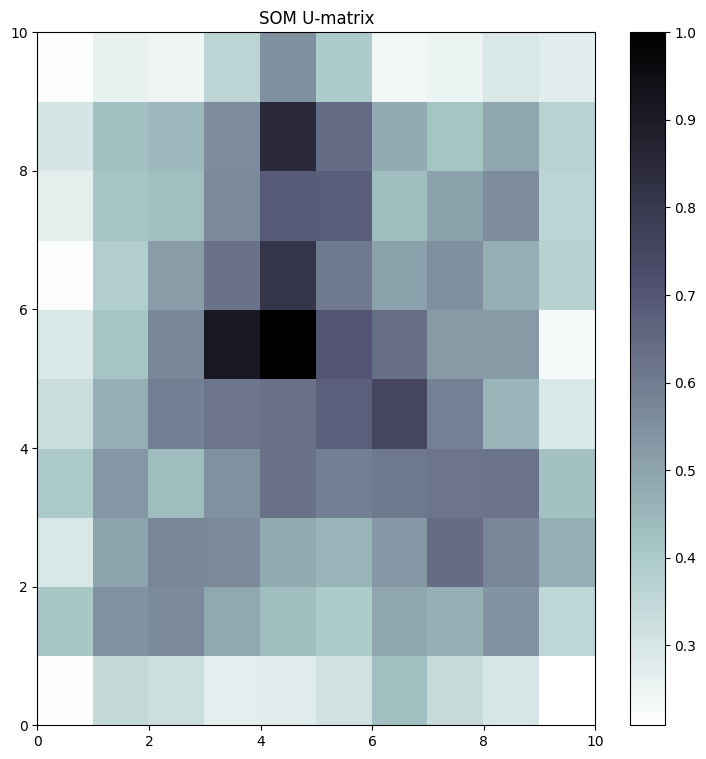

/tmp/ipython-input-4059110449.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_targets))


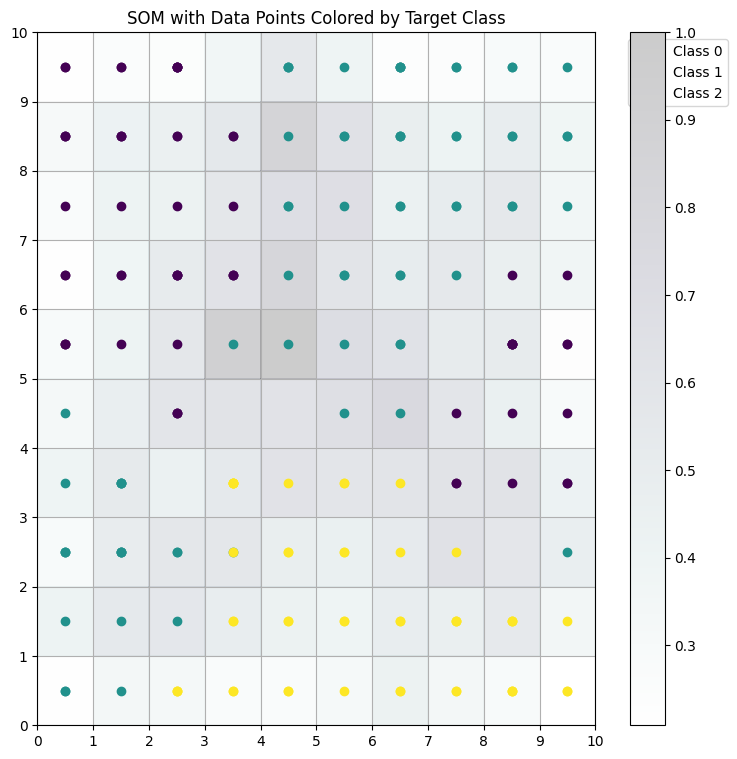

In [ ]:
import matplotlib.pyplot as plt

# 1. U-matrix Visualization
plt.figure(figsize=(9, 9))
plt.title('SOM U-matrix')
plt.pcolor(som.distance_map().T, cmap='bone_r')  # Transposed for proper orientation
plt.colorbar()
plt.show()

# 2. Map data points to their Best Matching Units (BMUs) and visualize

# Get the 'target' column for coloring, ensuring it's an array for indexing
target_labels = df['target'].values

# Create a dictionary to map target values to colors
# Assuming 'target' contains discrete categories, e.g., 0, 1, 2 for the Wine dataset
unique_targets = np.unique(target_labels)
colors = plt.cm.get_cmap('viridis', len(unique_targets))

plt.figure(figsize=(9, 9))
plt.pcolor(som.distance_map().T, cmap='bone_r', alpha=0.2) # U-matrix as background, slightly transparent
plt.colorbar()

# Iterate through each data point to find its BMU and plot it
for i, x in enumerate(df_scaled.values):
    w = som.winner(x)
    # Place the data point's BMU in the center of the cell
    plt.plot(w[0] + 0.5, w[1] + 0.5, 'o',
             markerfacecolor=colors(target_labels[i]),
             markeredgecolor=colors(target_labels[i]),
             markersize=6, markeredgewidth=1)

# Create custom legend handles for each target class
legend_handles = []
for class_id in unique_targets:
    handle = plt.plot([], [], 'o',
                      markerfacecolor=colors(class_id),
                      markeredgecolor=colors(class_id),
                      markersize=8, markeredgewidth=1,
                      label=f'Class {class_id}')
    legend_handles.append(handle[0])

plt.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.25, 1))
plt.title('SOM with Data Points Colored by Target Class')
plt.xticks(np.arange(som_grid_rows + 1))
plt.yticks(np.arange(som_grid_columns + 1))
plt.grid()
plt.show()


**Reasoning**:
The previous code generated a `MatplotlibDeprecationWarning` because `plt.cm.get_cmap` is deprecated. I will update the code to use the recommended `plt.get_cmap` to ensure compatibility with newer Matplotlib versions and suppress the warning.



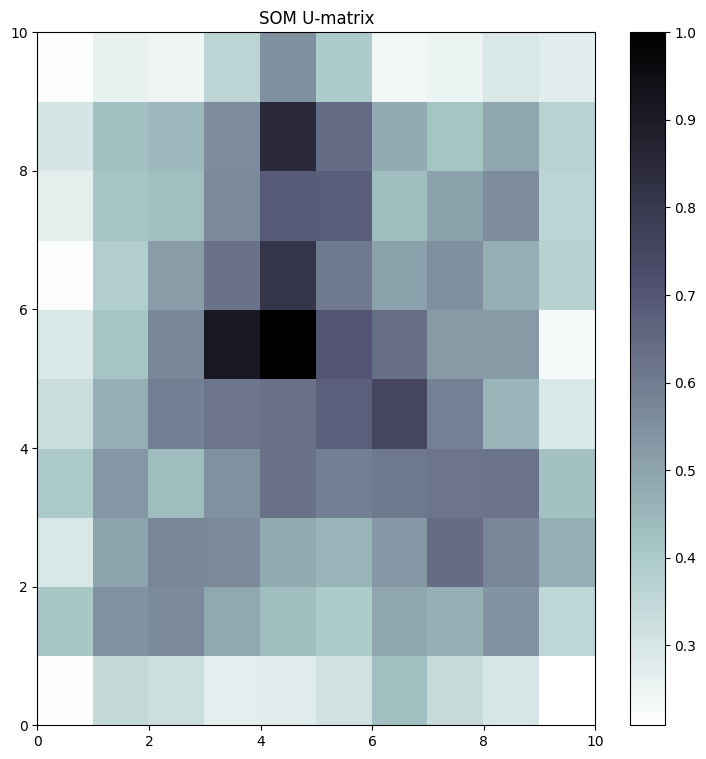

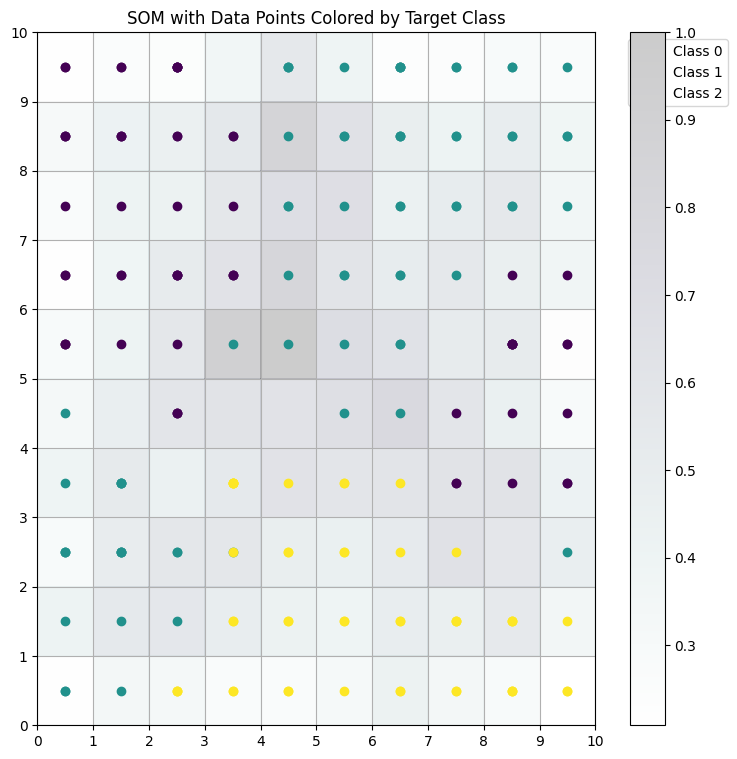

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy as it's used in this cell

# 1. U-matrix Visualization
plt.figure(figsize=(9, 9))
plt.title('SOM U-matrix')
plt.pcolor(som.distance_map().T, cmap='bone_r')  # Transposed for proper orientation
plt.colorbar()
plt.show()

# 2. Map data points to their Best Matching Units (BMUs) and visualize

# Get the 'target' column for coloring, ensuring it's an array for indexing
target_labels = df['target'].values

# Create a dictionary to map target values to colors
# Assuming 'target' contains discrete categories, e.g., 0, 1, 2 for the Wine dataset
unique_targets = np.unique(target_labels)
colors = plt.get_cmap('viridis', len(unique_targets)) # Updated from plt.cm.get_cmap

plt.figure(figsize=(9, 9))
plt.pcolor(som.distance_map().T, cmap='bone_r', alpha=0.2) # U-matrix as background, slightly transparent
plt.colorbar()

# Iterate through each data point to find its BMU and plot it
for i, x in enumerate(df_scaled.values):
    w = som.winner(x)
    # Place the data point's BMU in the center of the cell
    plt.plot(w[0] + 0.5, w[1] + 0.5, 'o',
             markerfacecolor=colors(target_labels[i]),
             markeredgecolor=colors(target_labels[i]),
             markersize=6, markeredgewidth=1)

# Create custom legend handles for each target class
legend_handles = []
for class_id in unique_targets:
    handle = plt.plot([], [], 'o',
                      markerfacecolor=colors(class_id),
                      markeredgecolor=colors(class_id),
                      markersize=8, markeredgewidth=1,
                      label=f'Class {class_id}')
    legend_handles.append(handle[0])

plt.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.25, 1))
plt.title('SOM with Data Points Colored by Target Class')
plt.xticks(np.arange(som_grid_rows + 1))
plt.yticks(np.arange(som_grid_columns + 1))
plt.grid()
plt.show()


**Reasoning**:
The subtask requests generating visualizations to interpret the SOM, including component planes. I have already generated the U-matrix and data point mapping. Now, I will visualize the component planes to show how each feature is represented across the SOM, providing insights into feature relationships within the clusters.



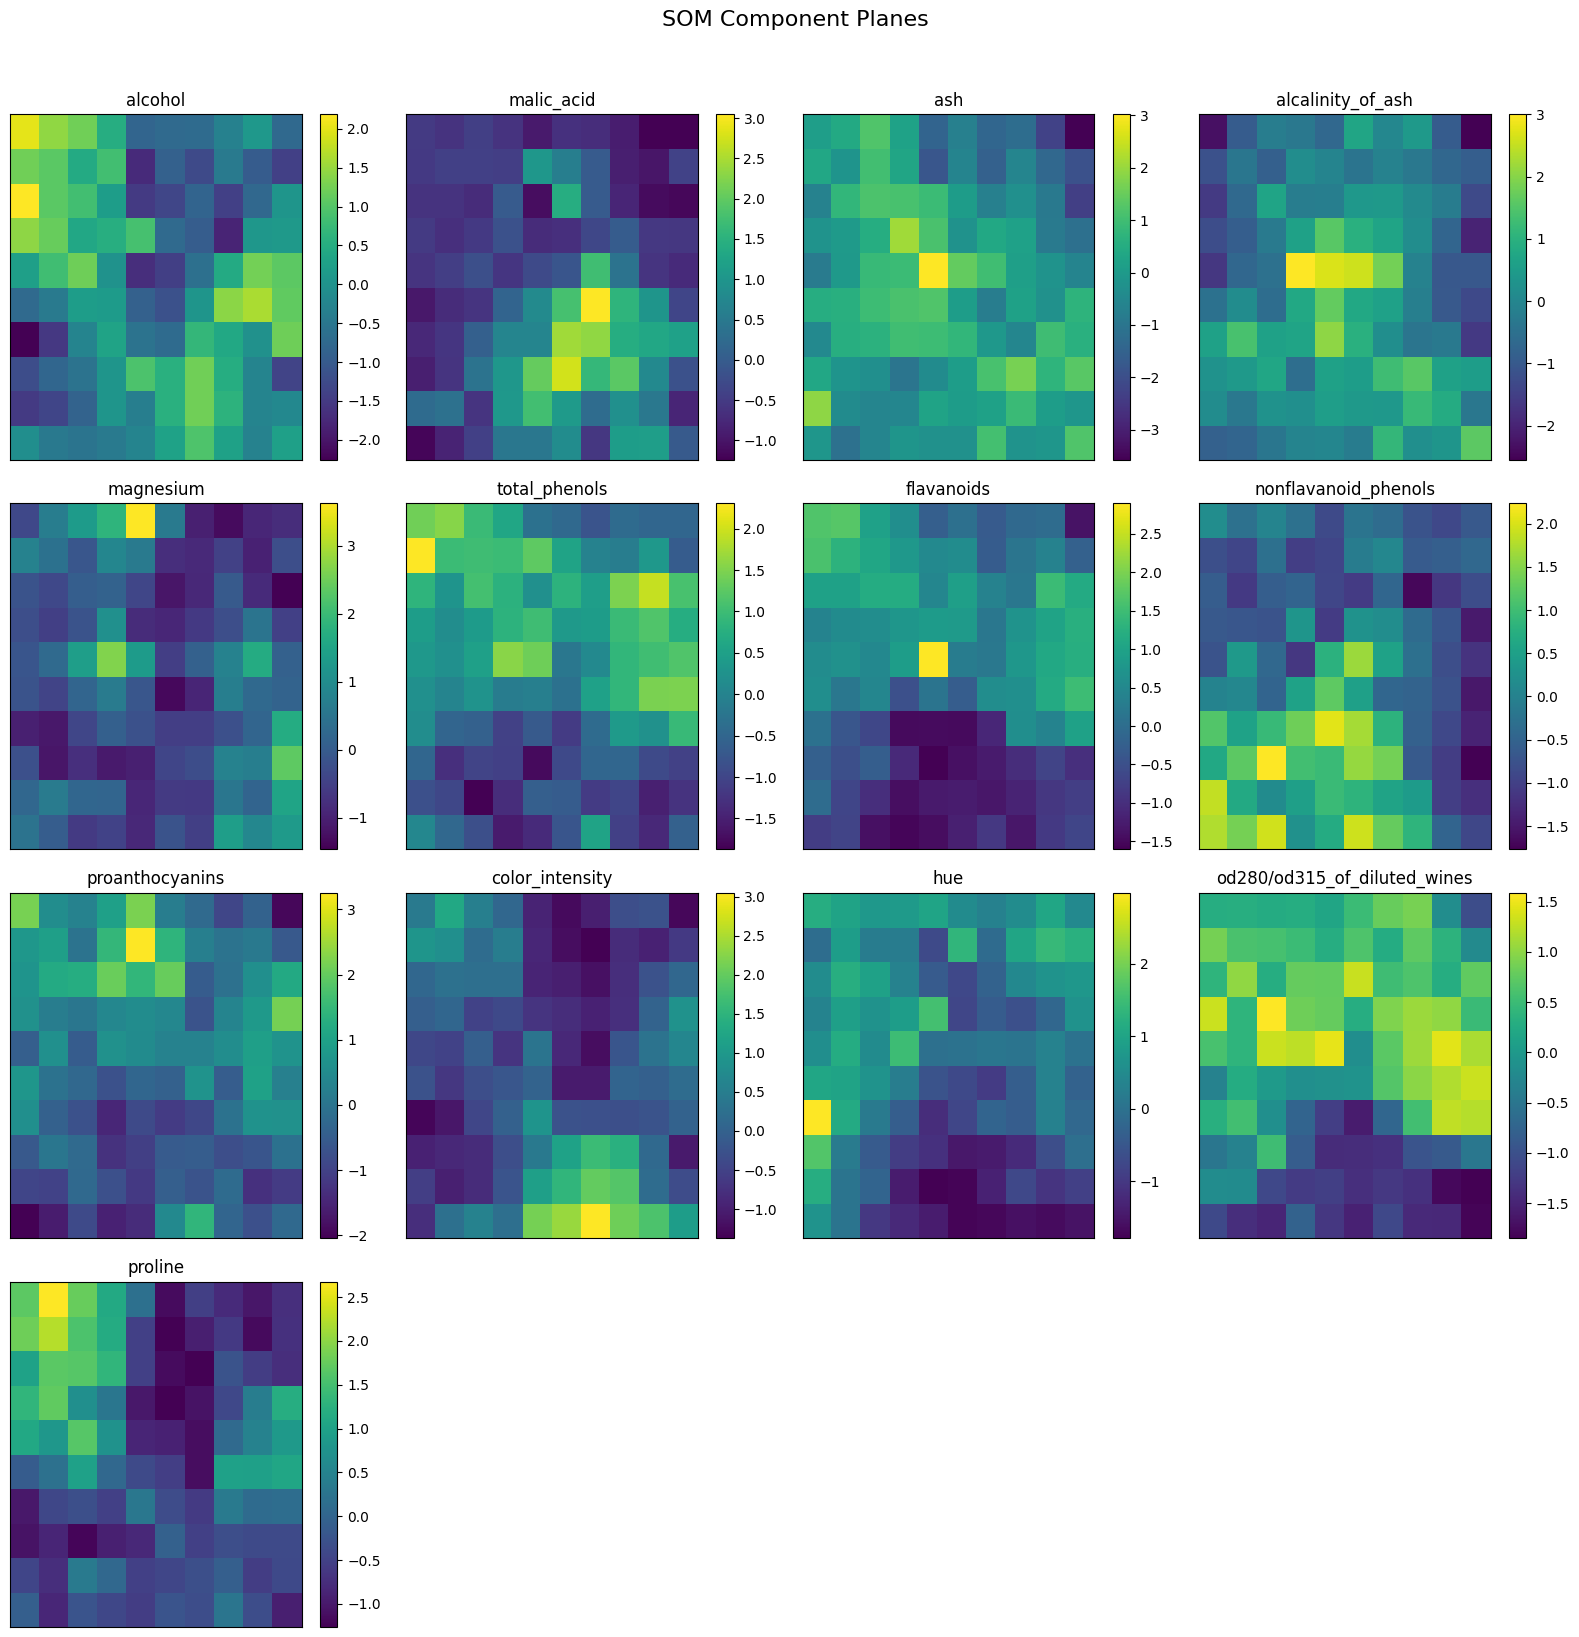

In [ ]:
num_features = df_scaled.shape[1]
feature_names = df_scaled.columns

# Calculate the number of rows and columns for the subplot grid dynamically
# Aim for a layout that is roughly square, or wider if more features.
n_cols = int(np.ceil(np.sqrt(num_features)))
n_rows = int(np.ceil(num_features / n_cols))

plt.figure(figsize=(n_cols * 4, n_rows * 4))
plt.suptitle('SOM Component Planes', fontsize=16, y=1.02)

for i, f_name in enumerate(feature_names):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.title(f_name)
    plt.pcolor(som.get_weights()[:, :, i].T, cmap='viridis')
    plt.colorbar()
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the insights gained from the SOM analysis, including any identified clusters or patterns in the dataset.


## Summary:

### Q&A
*   **Summarize the insights gained from the SOM analysis, including any identified clusters or patterns in the dataset.**
    The Self-Organizing Map (SOM) analysis revealed clear clustering patterns within the Wine dataset. The U-matrix visualization, with its distinct regions of low activation (darker areas) separated by high activation boundaries (lighter areas), strongly suggests the presence of natural clusters. When the data points were mapped to their Best Matching Units (BMUs) and colored according to their original 'target' class, it became evident that the SOM successfully organized the data, grouping samples from the same wine class together. This indicates at least three well-separated clusters on the map, corresponding to the three distinct wine types. The component planes further illustrated how individual features contribute to these clusters, showing varying distributions of feature weights across the map for attributes like 'alcohol', 'flavanoids', and 'color_intensity', suggesting their significance in differentiating the wine varieties.

### Data Analysis Key Findings
*   The 'Wine' dataset was successfully loaded, comprising 178 entries and 13 numerical features, along with a 'target' column. No missing values were identified in the dataset.
*   All 13 numerical features were preprocessed by scaling them using `StandardScaler`, a necessary step for SOM analysis.
*   A 10x10 Self-Organizing Map (SOM) was successfully initialized and trained for 10,000 iterations on the scaled data, organizing the high-dimensional input into a 2D topological map.
*   The U-matrix visualization displayed distinct areas of high and low similarity, providing a visual indication of potential clusters and boundaries within the dataset.
*   Mapping data points to their Best Matching Units (BMUs) and coloring them by their original 'target' class showed that the SOM effectively grouped samples belonging to the same wine class, demonstrating clear separation between the three wine varieties.
*   Component plane visualizations for each of the 13 features were generated, illustrating how individual features contribute to the overall structure and clustering identified by the SOM.

### Insights or Next Steps
*   The SOM effectively identifies and visualizes the inherent clustering structure within the Wine dataset, aligning well with the known classification of wine types. This demonstrates the SOM's utility in unsupervised exploratory data analysis for discovering underlying patterns.
*   A logical next step would be to perform quantitative cluster evaluation. This could involve assigning each SOM node to a class based on the majority of its mapped samples and then evaluating the accuracy of this unsupervised classification against the true 'target' labels, or by calculating metrics like the Silhouette Score.
